# Task 1. Для изображения sar_3.jpg найти наиболее протяженный участок.

# Исходное изображение

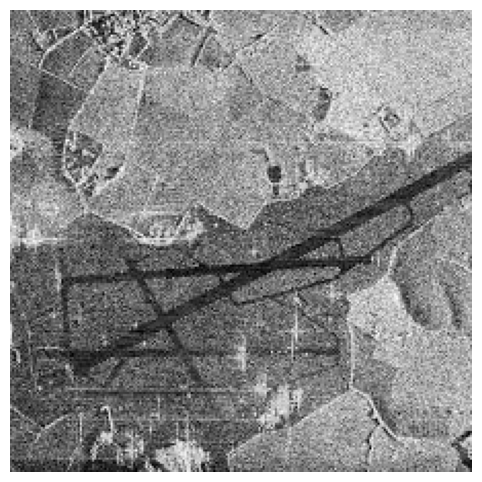

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

image = cv2.imread("sar_3.jpg")
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(6, 6))
plt.imshow(image_gray, cmap="gray")
plt.axis("off")
plt.show()

# Наиболее протяженный участок. Преобразование Хафа

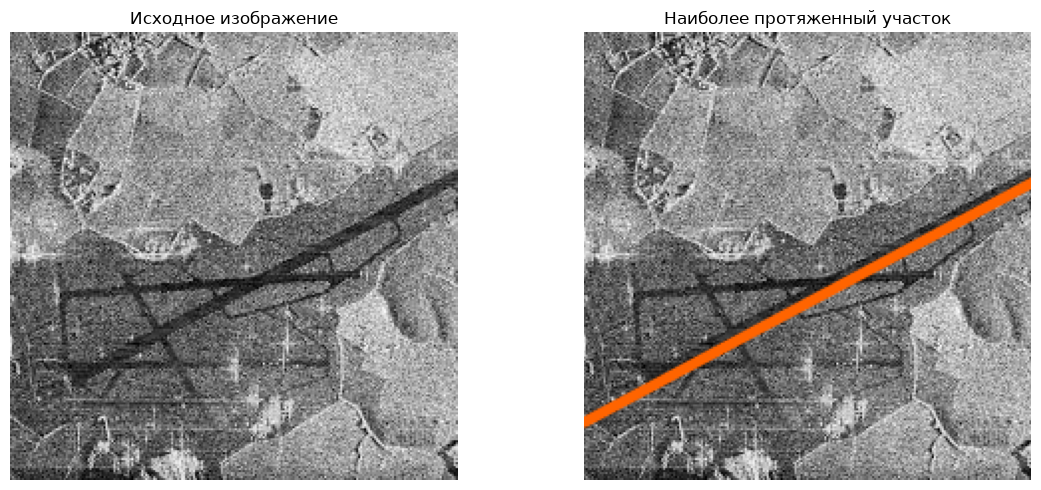

In [2]:
edges = cv2.Canny(image_gray, 100, 150, apertureSize=3) 
lines = cv2.HoughLines(edges, 1, np.pi/180, 140) 

max_length = 0
longest_line = None
image_with_lines = image.copy()

if lines is not None:
    for line in lines:
        rho, theta = line[0]
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho
        pt1 = (int(x0 + 1000*(-b)), int(y0 + 1000*(a)))
        pt2 = (int(x0 - 1000*(-b)), int(y0 - 1000*(a)))
        length = np.sqrt((pt1[0] - pt2[0])**2 + (pt1[1] - pt2[1])**2)
        
        if length > max_length:
            max_length = length
            longest_line = (pt1, pt2)

if longest_line is not None:
    cv2.line(image_with_lines, longest_line[0], longest_line[1], (0, 100, 255), 3, cv2.LINE_AA)

plt.figure(figsize=(12, 5))  

plt.subplot(1, 2, 1) 
plt.imshow(image, cmap='gray')
plt.title('Исходное изображение')
plt.axis('off')

plt.subplot(1, 2, 2)  
plt.imshow(cv2.cvtColor(image_with_lines, cv2.COLOR_BGR2RGB))
plt.title('Наиболее протяженный участок')
plt.axis('off')

plt.tight_layout()
plt.show()

# Task 2: Для изображения sar_3.jpg провести исследование алгоритмов бинаризации, выделить участок дорожной полосы.

# Точечная бинаризация

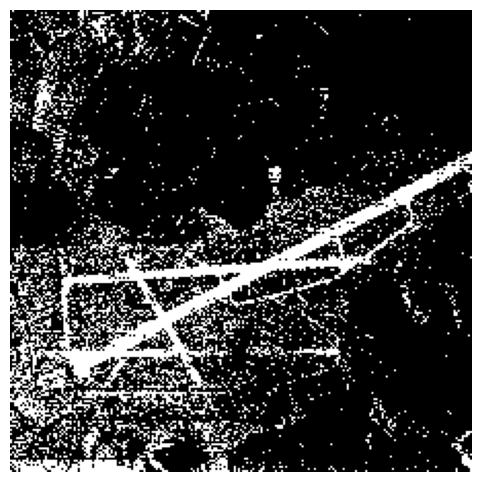

In [3]:
T = 80
_, binary_fixed = cv2.threshold(image_gray, T, 255, cv2.THRESH_BINARY_INV)

plt.figure(figsize=(6, 6))
plt.imshow(binary_fixed, cmap="gray")
plt.axis("off")
plt.show()

# Бинаризация Отсу

Порог Отсу: 129


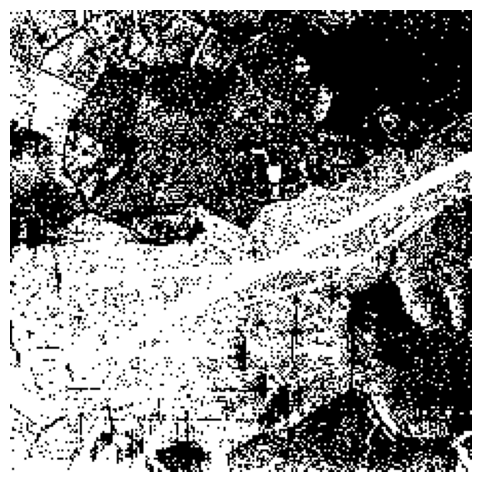

In [4]:
T_otsu, binary_otsu = cv2.threshold(
    image_gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

print(f"Порог Отсу: {T_otsu:.0f}")

plt.figure(figsize=(6, 6))
plt.imshow(binary_otsu, cmap="gray")
plt.axis("off")
plt.show()

# Адаптивная бинаризация

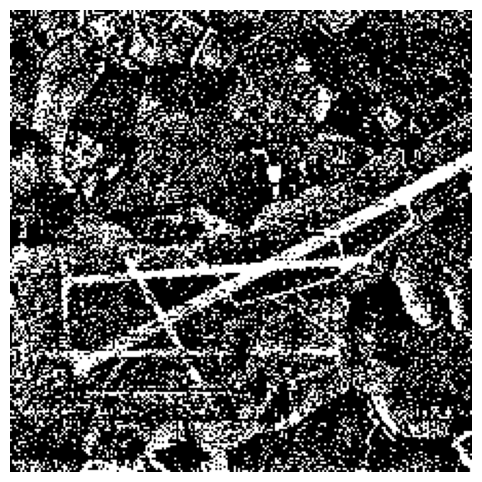

In [5]:
binary_adaptive = cv2.adaptiveThreshold(
    image_gray, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    71, 21
)

plt.figure(figsize=(6, 6))
plt.imshow(binary_adaptive, cmap="gray")
plt.axis("off")
plt.show()

# Сравнение методов бинаризации

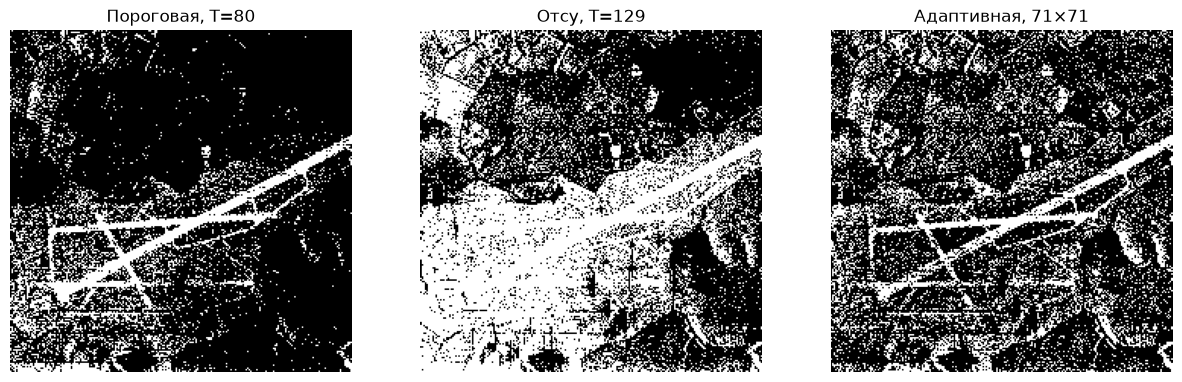

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(binary_fixed, cmap="gray")
axes[0].set_title("Пороговая, T=80")
axes[0].axis("off")

axes[1].imshow(binary_otsu, cmap="gray")
axes[1].set_title(f"Отсу, T={T_otsu:.0f}")
axes[1].axis("off")

axes[2].imshow(binary_adaptive, cmap="gray")
axes[2].set_title("Адаптивная, 71×71")
axes[2].axis("off")

plt.show()

Более четко выделяют участок дороги Адаптивная бинаризация со значениями (71, 21) и Пороговая со значением Т = 80. Бинаризация Отсу показала худший вариант. 

# Выделение участка дорожной полосы

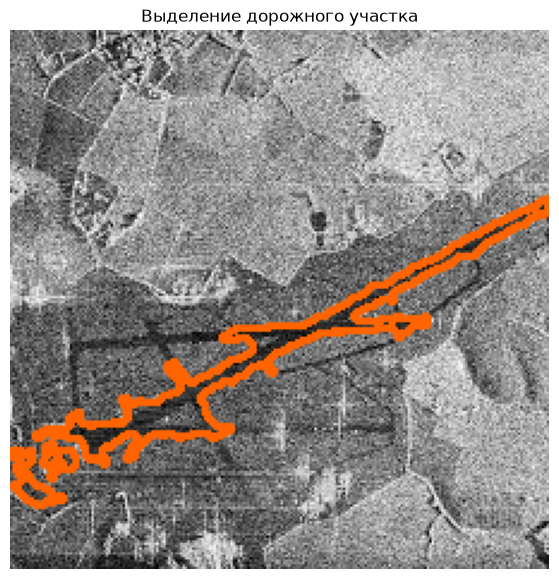

In [7]:
blurred = cv2.GaussianBlur(image_gray, (5, 5), 0)

road_area = np.zeros_like(image_gray)

pt1 = (3, 193)
pt2 = (220, 78)

cv2.line(road_area, pt1, pt2, 255, thickness=35)

T = 80
_, road_thresh = cv2.threshold(
    blurred, T, 255, cv2.THRESH_BINARY_INV
)

road_mask = cv2.bitwise_and(road_thresh, road_area)

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
road_mask = cv2.morphologyEx(
    road_mask, cv2.MORPH_OPEN, kernel
)
road_mask = cv2.morphologyEx(
    road_mask, cv2.MORPH_CLOSE, kernel
)

contours, _ = cv2.findContours(
    road_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
)

lane_image = image.copy()

for contour in contours:
    if cv2.contourArea(contour) > 30:
        cv2.drawContours(
            lane_image, [contour], -1, (0, 100, 255), 2
        )

plt.figure(figsize=(7, 7))
plt.imshow(cv2.cvtColor(lane_image, cv2.COLOR_BGR2RGB))
plt.title("Выделение дорожного участка")
plt.axis("off")
plt.show()